# FIFA World Cup 2026 — SQL Data Analysis

### Аналіз голів, гравців, команд та ліг

## Project Overview

This project analyzes FIFA World Cup 2026 data using SQL.

The analysis focuses on:
- goal distribution across leagues;
- player performance;
- team performance;
- expected goals (xG) vs actual goals;
- goals and assists;
- player positions;
- match statistics.

The analysis uses PostgreSQL and demonstrates SQL techniques including:
- JOINs;
- aggregations;
- GROUP BY;
- CTEs;
- window functions;
- CASE expressions.

In [23]:
import pandas as pd
from sqlalchemy import create_engine


In [ ]:
# Database connection is not included in the public repository.

## 1. Клуби, чиї гравці забили найбільше

### Завдання

Провести Аналіз голів в розрізі футбольних клубів та їхніх гравців.
Зробити зрозумілу візуалізацію по основним результатам.

Для кожного клубу розраховано:
- `total_goals` — загальна кількість забитих голів;
- `total_players` — кількість різних гравців клубу, які забили хоча б один гол.

In [19]:
query = """
SELECT                                              --
    p.club,
    COUNT(g.goal_id) AS total_goals,
    COUNT(DISTINCT g.player_id) AS total_players
FROM goals g
JOIN players p
    ON g.player_id = p.player_id
GROUP BY p.club
ORDER BY total_goals DESC;
"""

df_clubs = pd.read_sql(query, engine)

df_clubs

,club,total_goals,total_players
0,Real Madrid,22,4
1,Paris Saint-Germain,16,9
2,Arsenal,13,7
3,Bayern München,9,4
4,Inter Miami CF,8,1
...,...,...,...
119,Slavia Prague,1,1
120,St. Pauli,1,1
121,Swansea City,1,1
122,Trabzonspor,1,1


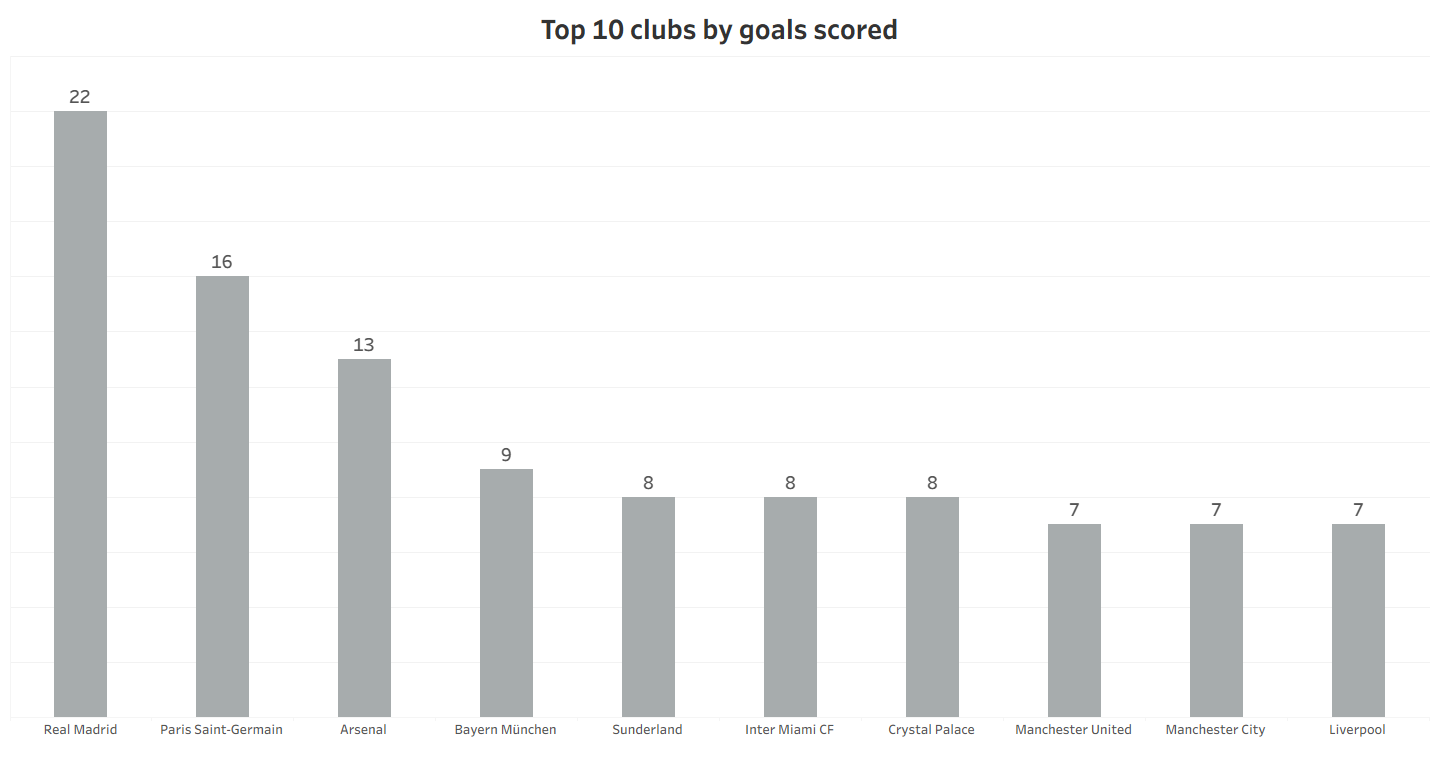 ; 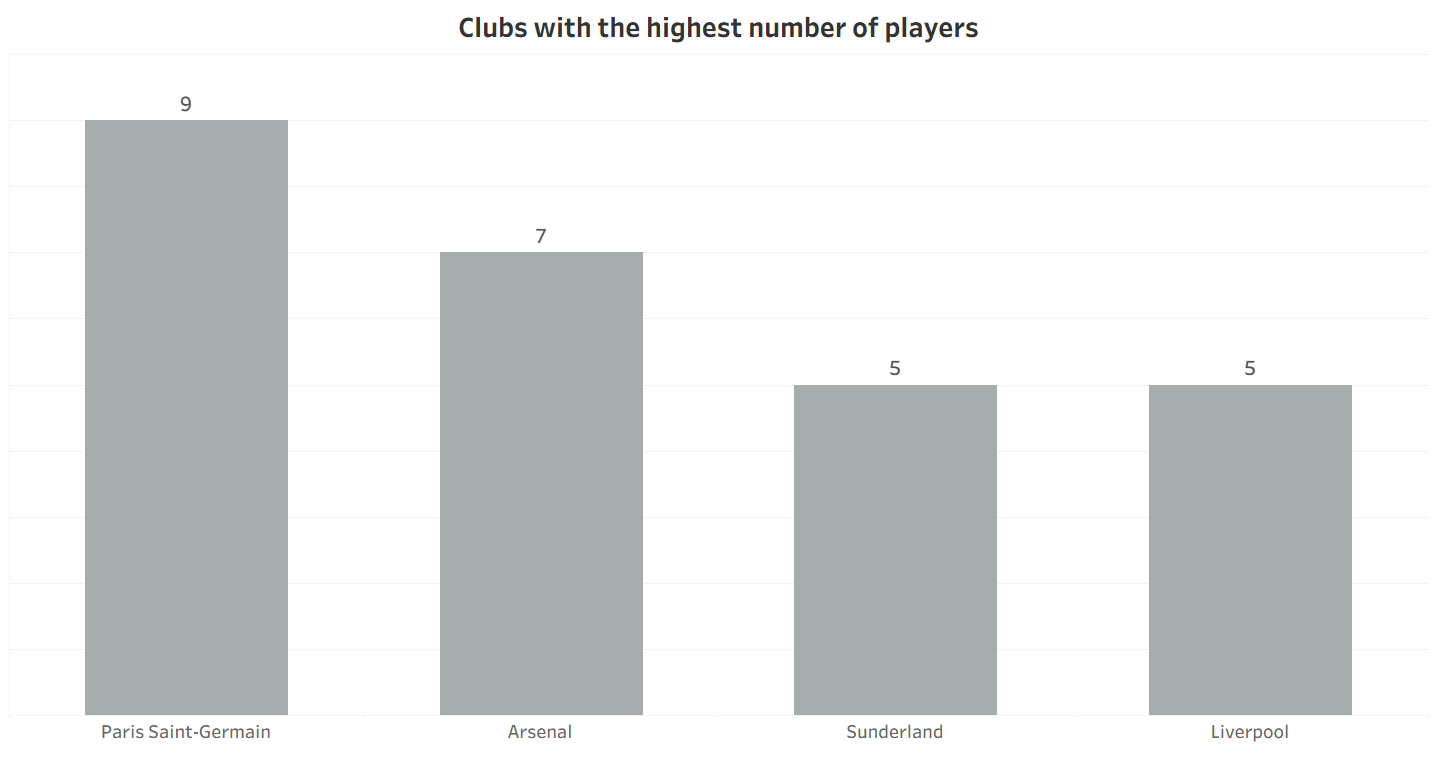

### Висновок
Всього на турнір відзначались гравці з **124 різних клубів**.

Можемо констатувати, що найбільш забивним клубом є **Real Madrid**. 4 різних автори голів забили сумарно **22 голи**, тоді як **Paris Saint-Germain** ( на 2-му місці ) з **16 голами** має аж 9 гравців, які відзначались мінімум одним голом.  

Також, цікавим є те, що в ТОП 10 цього рейтингу **Inter Miami CF** та **Manchester City**, маючи лише по **одному** представнику. 




## 2. Залежність команд від нійкращого бомбардира. 

## Завдання
Визначити команди, у яких найкращий бомбардир забив понад третину всіх голів команди.
До аналізу включені лише команди, які забили **10 і більше голів** на турнірі.

In [27]:
query = """
with  cte_1 as(															  -- Виводимо гравців кожної команди які забивали та к-сть цих голів
select  count(g.goal_id ) as goals, g.player_name , g.team_name 
from goals g 
group by g.player_name , g.team_name
),
ranked_players as														  -- Додаємо к-сть голів кожної команди, 
(                                                                         -- а також визначаємо кращого бомбардира
select goals
	   ,player_name 
	   ,team_name 
	   ,SUM(goals) OVER (PARTITION BY team_name) AS team_goals
	   ,rank() over(partition by team_name order by goals desc) number_one
from cte_1
),
scorer_share as															  -- Показуємо вагу кращих бомбардирів команди, додатково фільтруючи
(																		  -- рейтинг по загальним голам команди 
select *
	   ,round( goals*100/team_goals, 2  ) as scorer_share
from ranked_players
where team_goals >= 10 and
number_one = 1 
order by scorer_share desc
)
select  team_name														  -- Виводимо список гравців, які забили більше третини голів своєї команди
	   ,player_name 
	   ,goals 
	   ,team_goals 
	   ,scorer_share 
from scorer_share 
where scorer_share > 33.33
"""

df_scorer_share = pd.read_sql(query,engine)
df_scorer_share

,team_name,player_name,goals,team_goals,scorer_share
0,Norway,Erling Haaland,7,13,54
1,France,Kylian Mbappé,10,20,50
2,Argentina,Lionel Messi,8,19,42
3,Mexico,Julián Quiñones,4,10,40
4,Brazil,Vinicius Junior,4,10,40
5,Senegal,Ismaïla Sarr,4,10,40
6,Spain,Mikel Oyarzabal,5,14,36
7,England,Jude Bellingham,7,20,35


## Висновок
Результат запиту показує 8 людей, які підходять під наші критерії. Але також бачимо, Також, варто уточнити, що є 2 гравці, які забили половину від усіх голів власної команди на ЧС. Загалом можна виділити першу трійку - їхній внесок в результативність команди вражає. Кожен з них забивав майже кожен другий гол команди, що в результаті і допомогло їхнім командам забити таку вражаючу к-сть голів на турнірі.  


## 3. Аналіз груп за результативністю та ринковою вартістю

### Завдання

Відобразити результативність кожної групи та розглянути взаємозв'язок між забитими голами та ринковою варістю цих груп.

Для кожної команди відображено:
- `team_value_eur` — ринкова вартість команди;
- `goals` — кількість голів цієї команди;
- `group_name` — назва групи.
Також, було виведено ці ж показники по кожній групі:
- `group_goals` — сумарна к-сть голів для кожної групи;
- `avg_value_for_group` — загальна ринкова вартість кожної групи.

In [28]:
query = """
with cte_1  as                                                                                    -- Робимо перше CTE. Змінюємо тип даних у колонці з 
	(                                                                                             -- варістю команд та прибираємо в ній зайві символи.
	select t.team_id 
		   ,team_name
		   ,REGEXP_REPLACE(t.team_market_value_eur, '[^0-9]', '', 'g')::numeric as team_value_eur
		   ,t.group_name 
	from teams t
)
,
team_goals  as                                                                                    -- Робимо підзапит у from. Два селекти, в яких 
(                                                                                                 -- сумуємо окремо голи домашньої команди та 
select sum(total_goals) as total_goals, team_id                                                   -- гостьової, об'єднуємо через union all. В такий
from (                                                                                            -- спосіб виводимо кількість глоів за матч. 
		select sum(m.home_goals) as total_goals ,m.home_team_id as team_id
		from matches m 
		where m.stage = 'Group Stage'
		group by m.home_team_id
		union all 
		select sum(m.away_goals) as total_goals ,m.away_team_id as team_id
		from matches m 
		where m.stage = 'Group Stage'
		group by  m.away_team_id)
group by team_id
)                                                                                                 -- Об'єднуємо два cte через join 
select  c.team_name
	   ,c.team_value_eur 
       ,c.group_name
	   ,AVG(c.team_value_eur ) over(partition by c.group_name ) as avg_value_for_group
	   ,t.total_goals  as goals
	   ,sum(t.total_goals ) over (partition by c.group_name ) as group_goals
from cte_1 c
join team_goals t on t.team_id = c.team_id
order by c.group_name
"""

In [17]:
df_groups = pd.read_sql(query, engine)

pd.options.display.float_format = '{:,.0f}'.format

df_groups

,team_name,team_value_eur,group_name,avg_value_for_group,goals,group_goals
0,South Korea,"139,050,000",A,"142,082,500",2,12
1,South Africa,"49,250,000",A,"142,082,500",2,12
2,Mexico,"191,850,000",A,"142,082,500",6,12
3,Czech Republic,"188,180,000",A,"142,082,500",2,12
4,Qatar,"19,930,000",B,"174,370,000",2,22
5,Switzerland,"332,500,000",B,"174,370,000",7,22
6,Bosnia and Herzegovina,"146,400,000",B,"174,370,000",5,22
7,Canada,"198,650,000",B,"174,370,000",8,22
8,Haiti,"55,900,000",C,"400,512,500",2,16
9,Scotland,"170,250,000",C,"400,512,500",1,16


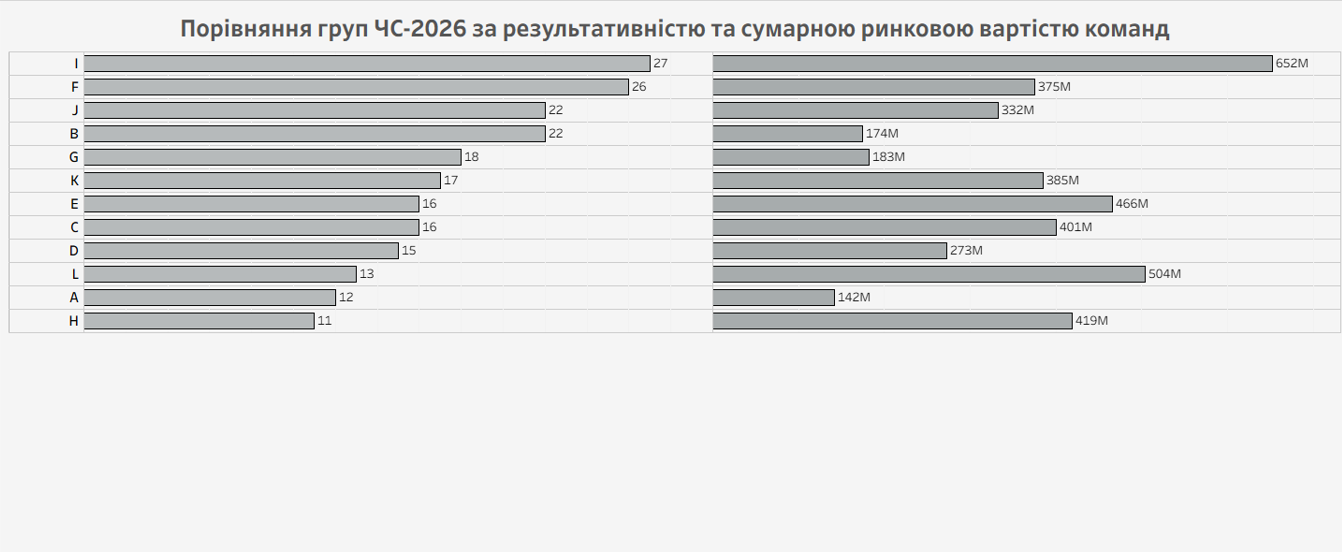

### Висновок

 Думка про те, що найдорожчі (найякісніші) команди будуть забивати найбільше, не завжди відповідає дійсності. Найрезультативнішою виявилася група F — 26 голів, яка водночас мала найвищу середню ринкову вартость серед команд. Водночас друга за середньою ринковою вартістю група L забила лише 13 голів, тобто вдвічі менше. 
 Отже, ринкова вартість гравців не має прямого пропорційного зв’язку з результативністю команд на груповому етапі. На кількість забитих голів впливає сукупність різних факторів, а не лише індивідуальна ринкова вартість гравців.


## 4. Розподіл голів між футбольними лігами

Проаналізовано, з яких футбольних ліг походили гравці, які забивали голи на Чемпіонаті світу 2026 року.

Окремо виділено 8 ліг із найбільшою кількістю голів, а всі інші ліги об'єднано в одну категорію. Додатково розраховано частку голів кожної групи від загальної кількості голів, кількість гравців та середню кількість голів на одного гравця.

In [12]:
query = """
WITH league_goals AS (   -- виводимо к-сть голів та заг. к-сть гравців, групуючи все по лігам
    SELECT
        p.league,
        COUNT(g.goal_id) AS goals,
        COUNT(DISTINCT p.player_id) AS total_players
    FROM players p
    LEFT JOIN goals g
        ON p.player_id = g.player_id
    GROUP BY p.league
),
ranked_leagues AS (      --
    SELECT
        league,
        goals,
        total_players,
        ROW_NUMBER() OVER (
            ORDER BY goals DESC
        ) AS league_rank,
        SUM(goals) OVER () AS total_goals
    FROM league_goals
),
grouped_leagues AS (
    SELECT
        CASE
            WHEN league_rank <= 8 THEN league
            ELSE 'Other 72 leagues'
        END AS league_group,
        SUM(goals) AS goals,
        MAX(total_goals) AS total_goals,
        SUM(total_players) AS total_players
    FROM ranked_leagues
    GROUP BY 1
)
SELECT
    league_group,
    goals,
    ROUND(
        goals * 100.0 / total_goals,
        1
    ) AS goal_share_percent,
    total_players,
    ROUND(
        goals * 1.0 / total_players,
        2
    ) AS goals_per_player
FROM grouped_leagues
ORDER BY goals DESC;
"""

In [7]:
df_leagues = pd.read_sql(query, engine)
df_leagues

,league_group,goals,goal_share_percent,total_players,goals_per_player
0,English Premier League,78.0,25.3,169.0,0.46
1,Other 72 leagues,74.0,24.0,629.0,0.12
2,Spanish LaLiga,45.0,14.6,83.0,0.54
3,Germany Bundesliga,29.0,9.4,104.0,0.28
4,French Ligue 1,25.0,8.1,80.0,0.31
5,Italian Serie A,21.0,6.8,66.0,0.32
6,Saudi Pro League,13.0,4.2,50.0,0.26
7,American MLS,13.0,4.2,45.0,0.29
8,Egyptian Premier League,10.0,3.2,22.0,0.45


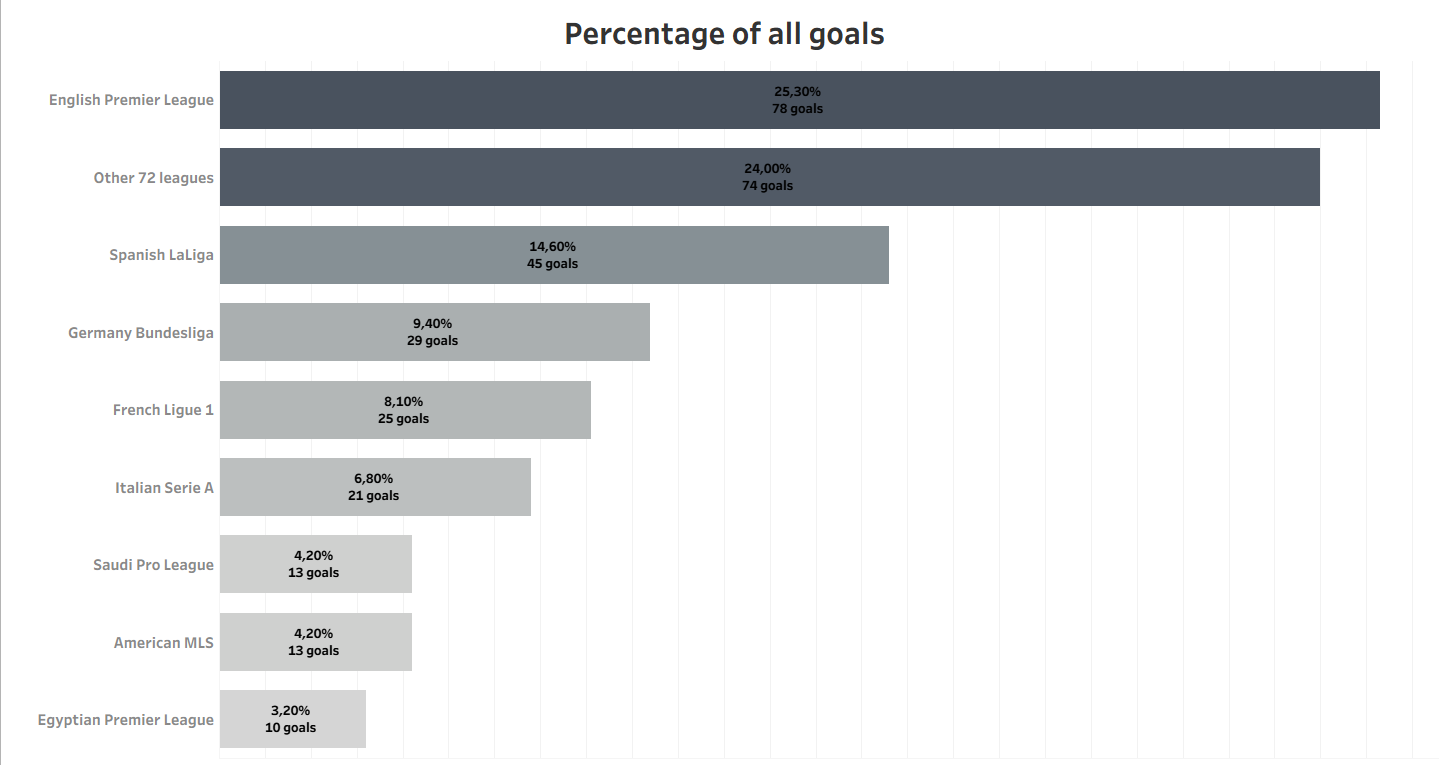
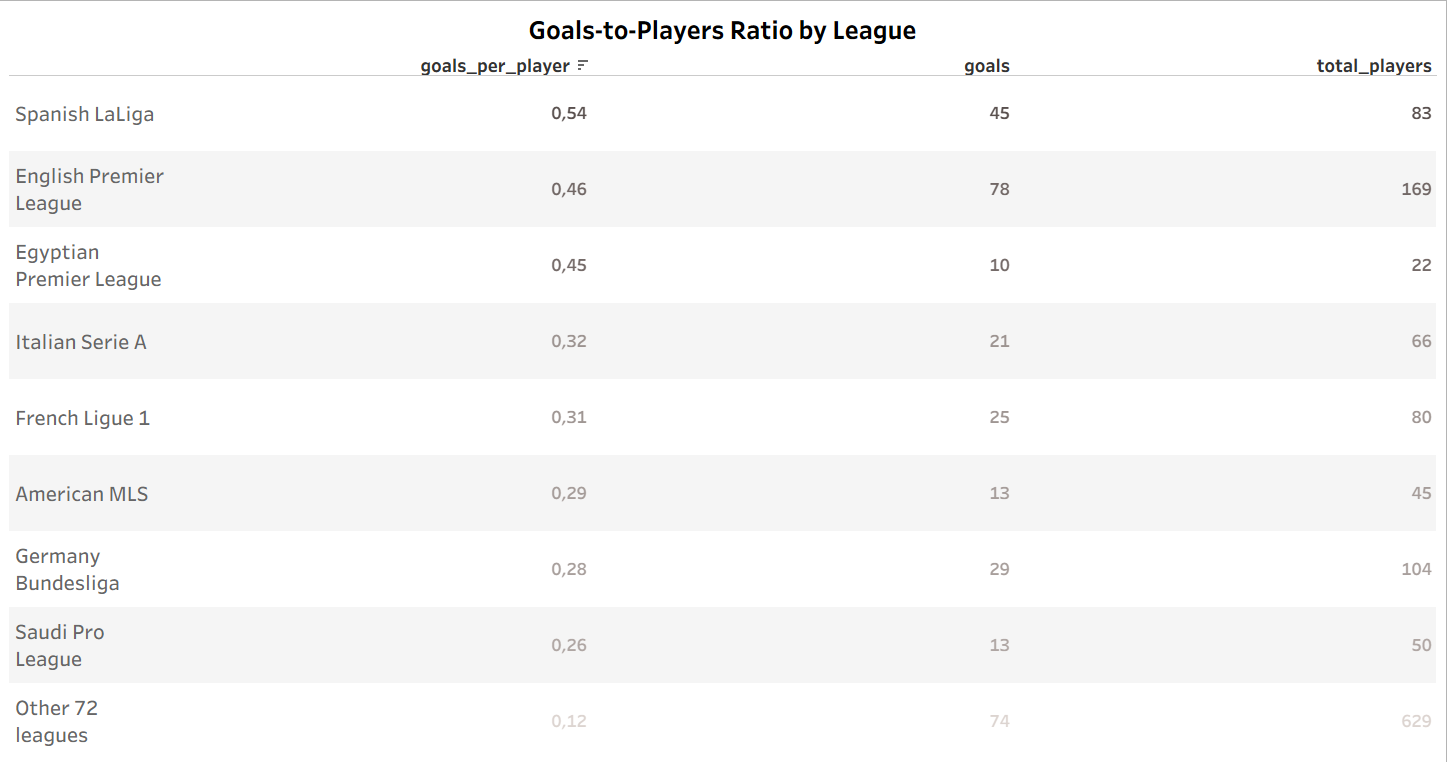

### Висновок

Англійська Прем'єр-ліга дала найбільшу кількість голів — 78, що становить 25% від усіх голів у вибірці. Ще 24% припадає на інші 72 ліги, які були об'єднані в одну категорію.

Серед окремих ліг найвищий показник голів на одного представленого гравця має іспанська LaLiga — 0,54. Для порівняння, Англійська Прем'єр-ліга має найбільшу абсолютну кількість голів, але 0,46 гола на одного гравця.

Це показує, що кількість голів та результативність у розрахунку на одного гравця — різні показники: велика кількість голів може бути пов'язана не лише з результативністю окремих гравців, а й з кількістю представлених гравців у лізі.